In [1]:
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
df.groupby('tip')['total_bill'].sum().reset_index()


,tip,total_bill
0,1.00,28.67
1,1.01,16.99
2,1.10,12.90
3,1.17,32.83
4,1.25,29.09
...,...,...
118,6.70,34.30
119,6.73,48.27
120,7.58,39.42
121,9.00,48.33


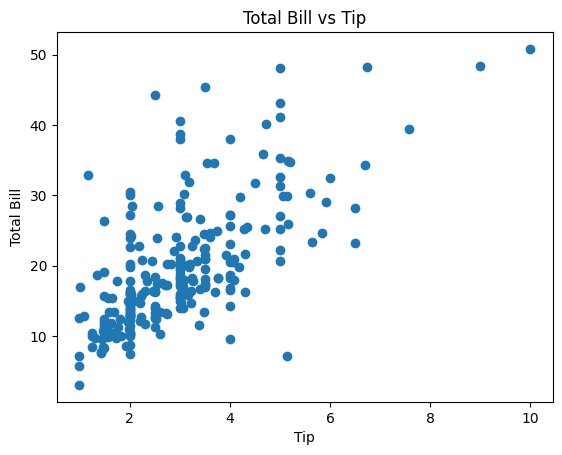

In [5]:
x = df['tip']
y = df['total_bill']
plt.scatter(x, y)
plt.title('Total Bill vs Tip')
plt.xlabel('Tip')   
plt.ylabel('Total Bill')
plt.show()

### FITTING THE REGRESSION LINE

In [6]:
from scipy import stats

slope,intercept ,r,p,std_err = stats.linregress(x,y)
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-value: {r}")

def myfucn(x):
    return slope*x + intercept  # basically it is y = m*x + c where m is slope and c is intercept

myfucn(x) #returns the predicted y values based on the linear regression model



Slope: 4.347714207346628
Intercept: 6.750283771267847
R-value: 0.6757341092113642


0      11.141475
1      13.967489
2      21.967283
3      21.141218
4      22.445532
         ...    
239    32.488752
240    15.445712
241    15.445712
242    14.358784
243    19.793426
Name: tip, Length: 244, dtype: float64

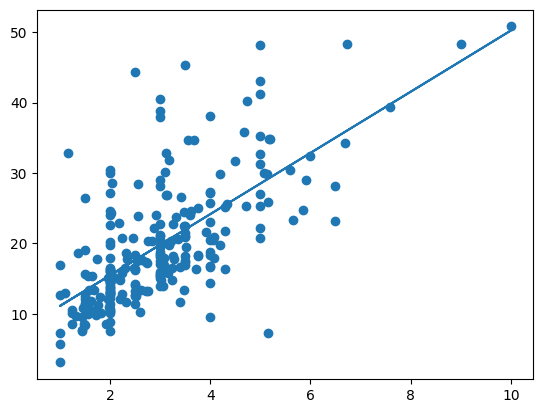

In [7]:
mymodel = list(map(myfucn,x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()


In [8]:
#predicting the total bill for a tip of 3.5
predicted_total_bill = myfucn(3.5)#we have the x which is a tip and we can predict the total bill using the linear regression model
print(f"Predicted Total Bill for a tip of 3.5: {predicted_total_bill}")

Predicted Total Bill for a tip of 3.5: 21.967283496981047


## conclusion
- Doing Linear Regression on this data was okay because there was a positive linear relationship between the two variables 

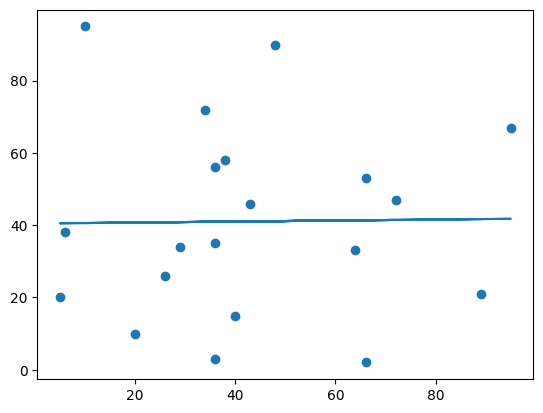

In [9]:
#CASE WHERE LINEAR REGRESSION MIGHT NOT BE THE BEST FIT
x = [89,43,36,36,95,10,66,34,38,20,26,29,48,64,6,5,36,66,72,40]
y = [21,46,3,35,67,95,53,72,58,10,26,34,90,33,38,20,56,2,47,15]
slope,intercept,r, p,std_err = stats.linregress(x,y)
def fun(x):
    return slope*x + intercept

model = list(map(fun, x))
plt.scatter(x,y)
plt.plot(x,model)
plt.show()

- There is a bad relationship between the two 

In [10]:
##test on my own without help
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [11]:
d = [1,2,3,4,5,6,7,8,9,10]
y = [2,4,5,7,11,13,17,19,23,29]

In [12]:
print(type(d))

<class 'list'>


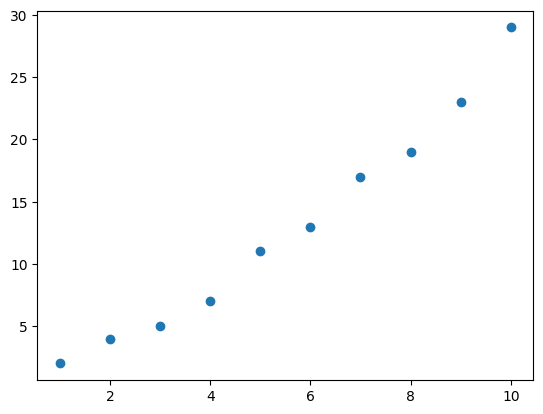

In [13]:
plt.scatter(d,y)

In [14]:
#fitting the regression line
from scipy import stats
slope,intercept,r,p,std_err = stats.linregress(d,y)

print("r :",r) #cheking the relationship ....shows there is a strong positive linear relationship 
print('slope:',slope)

r : 0.9847405476492448
slope: 2.8969696969696974


In [15]:
#defining a function that returns the predicted values of y 
d = np.array(d) 


In [16]:
def pred_func(d):
    return slope *d + intercept

pred_func(d)

array([-0.03636364,  2.86060606,  5.75757576,  8.65454545, 11.55151515,
       14.44848485, 17.34545455, 20.24242424, 23.13939394, 26.03636364])

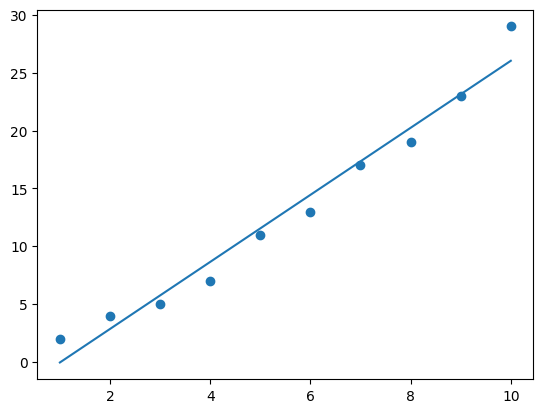

In [19]:
my_model = list(map(pred_func,d))
plt.scatter(d,y)
plt.plot(d,my_model)
plt.show()

In [18]:
predicted_value = pred_func(20)
predicted_value

np.float64(55.006060606060615)